In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", None)

sns.set_theme(style='whitegrid')

In [3]:
from pathlib import Path
import shutil
import kagglehub

# Download the dataset, then copy it into a project-local dataset folder.
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
dataset_dir = project_root / "dataset"
dataset_dir.mkdir(parents=True, exist_ok=True)

cache_path = Path(kagglehub.dataset_download("thoughtvector/customer-support-on-twitter"))

for item in cache_path.iterdir():
    destination = dataset_dir / item.name
    if item.is_dir():
        shutil.copytree(item, destination, dirs_exist_ok=True)
    else:
        shutil.copy2(item, destination)

print("Path to dataset files:", dataset_dir.resolve())

c:\Users\Kayan\OneDrive\Desktop\SE Factory\week3_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week3_project\dataset


In [4]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
twcs_path = project_root / "dataset" / "twcs" / "twcs.csv"

RANDOM_STATE = 42

df = pd.read_csv(twcs_path)
df.head()


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [5]:
# Keep only inbound tweets with non-null tweet_id and text.
filtered_df = df.loc[df["inbound"] == True, ["tweet_id", "text"]].dropna().reset_index(drop=True)
filtered_df = filtered_df.dropna(subset=['text'])
filtered_df = filtered_df[filtered_df["text"].str.len() > 20]

def is_support_reply(t):
    t = t.lower()
    patterns = ["please dm", "we're sorry", "let us know", "contact us", "thanks for reaching"]
    return any(p in t for p in patterns)

filtered_df = filtered_df[~filtered_df["text"].apply(is_support_reply)]
filtered_df.head()


,tweet_id,text
0,2,@sprintcare and how do you propose we do that
1,3,@sprintcare I have sent several private messages and no one is responding as usual
3,8,@sprintcare is the worst customer service
4,12,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯
5,16,@sprintcare Since I signed up with you....Since day 1


In [14]:
URGENT_PATTERNS = {
    "security_billing": [r"\brefund\b", r"\bcharged\b", r"\bfraud\b", r"\bhacked\b", r"\bstolen\b", r"\bunauthorized\b"],
    "access_lockout": [r"\blocked\b", r"\blocked out\b", r"\baccount locked\b", r"\bcannot login\b", r"\bcan[' ]?t login\b", r"\bcant login\b"],
    "service_failure": [r"\bnot working\b", r"\bservice down\b", r"\boutage\b", r"\bbroken\b", r"\bfailed\b", r"\berror\b", r"\bwon[' ]?t work\b", r"\bunable to\b", r"\bsession has expired\b"],
    "time_sensitive": [r"\basap\b", r"\burgent\b", r"\bimmediately\b", r"\bright now\b", r"\btoday\b", r"\bnow\b"],
    "travel_order": [r"\bflight\b", r"\bbooking\b", r"\bdelivery\b", r"\border\b", r"\breservation\b", r"\bcheck[- ]?in\b"],
    "frustration": [r"\bworst\b", r"\bridiculous\b", r"\bunacceptable\b", r"\bangry\b", r"\bdisappointed\b", r"\bunsafe\b"]
}

NON_URGENT_PATTERNS = [
    r"\bthank you\b",
    r"\bthanks\b",
    r"\bgreat service\b",
    r"\bjust wondering\b",
    r"\bfeature request\b"
]

CATEGORY_WEIGHTS = {
    "security_billing": 3,
    "access_lockout": 3,
    "service_failure": 2,
    "time_sensitive": 2,
    "travel_order": 1,
    "frustration": 1
}

compiled_urgent_patterns = {
    category: [re.compile(pattern) for pattern in patterns]
    for category, patterns in URGENT_PATTERNS.items()
}

compiled_non_urgent_patterns = [re.compile(pattern) for pattern in NON_URGENT_PATTERNS]

def normalize_text(text):
    text = str(text)
    return re.sub(r"\s+", " ", text).strip()

def score_priority(text):
    text = normalize_text(text)
    t = text.lower()
    score = 0

    for category, patterns in compiled_urgent_patterns.items():
        if any(pattern.search(t) for pattern in patterns):
            score += CATEGORY_WEIGHTS[category]

    if text.count("!") >= 2:
        score += 1

    alpha_count = sum(char.isalpha() for char in text)
    upper_ratio = sum(char.isupper() for char in text if char.isalpha()) / max(1, alpha_count)
    if upper_ratio > 0.3:
        score += 1

    if any(phrase in t for phrase in ["still not fixed", "again", "for hours", "for days", "no one is responding"]):
        score += 1

    if any(pattern.search(t) for pattern in compiled_non_urgent_patterns):
        score -= 2

    # Travel or order mentions matter more when paired with failure or time pressure.
    if any(pattern.search(t) for pattern in compiled_urgent_patterns["travel_order"]):
        if any(pattern.search(t) for pattern in compiled_urgent_patterns["time_sensitive"] + compiled_urgent_patterns["service_failure"]):
            score += 1

    return score

def label_priority(text):
    return "urgent" if score_priority(text) >= 3 else "normal"


In [32]:
# Label the full cleaned dataset automatically.
filtered_df = filtered_df.copy()
filtered_df["priority_score"] = filtered_df["text"].apply(score_priority)
filtered_df["label"] = np.where(filtered_df["priority_score"] >= 2, "urgent", "normal")

filtered_df[["tweet_id", "text", "priority_score", "label"]].head()


,tweet_id,text,priority_score,label
0,2,@sprintcare and how do you propose we do that,0,normal
1,3,@sprintcare I have sent several private messages and no one is responding as usual,1,normal
3,8,@sprintcare is the worst customer service,1,normal
4,12,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯,0,normal
5,16,@sprintcare Since I signed up with you....Since day 1,0,normal


In [33]:
priority_3_rows = filtered_df[filtered_df['priority_score'] >= 2]

print('Number of rows with priority score = 3:', priority_3_rows.shape[0])
priority_3_rows.head()


Number of rows with priority score = 3: 225308


,tweet_id,text,priority_score,label
12,29,actually that's a broken link you sent me and incorrect information https://t.co/V4yfrHR8VI,2,urgent
34,69,@ChipotleTweets messed up today and didn’t give me my $3 burrito although I was dressed up 😭,2,urgent
40,153,"Happy Halloween! Since I'm too old to trick or treat I now look forward to $3 booritos at @ChipotleTweets 👻 I got mine earlier, did you?",2,urgent
42,156,So frustrated with @ChipotleTweets 😡 Ordered dinner on Saturday using their app. Order was wrong AND they charged my credit card twice,4,urgent
55,183,@AskPlayStation It was when I would go to download it. I just waited a few hours till after I bought it and it downloaded now.,2,urgent


In [34]:
# Inspect class balance before splitting.
class_balance = filtered_df["label"].value_counts().rename_axis("label").reset_index(name="count")
class_balance["percentage"] = (class_balance["count"] / len(filtered_df) * 100).round(2)
class_balance


,label,count,percentage
0,normal,1279506,85.03
1,urgent,225308,14.97


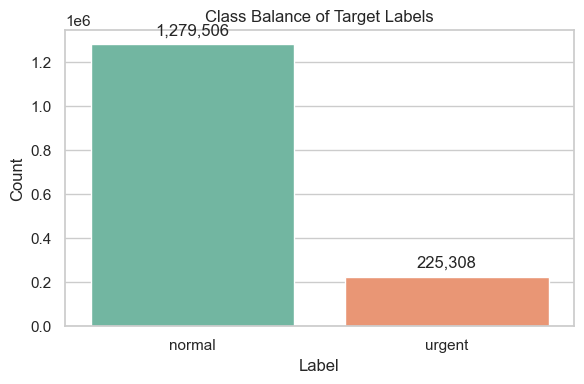

In [35]:
# Chart the class balance of the target labels.
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=class_balance, x="label", y="count", hue="label", palette="Set2", legend=False)
ax.set_title("Class Balance of Target Labels")
ax.set_xlabel("Label")
ax.set_ylabel("Count")

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()


In [36]:
# Inspect a few urgent examples before splitting.
urgent_examples = filtered_df.loc[
    filtered_df["label"] == "urgent",
    ["tweet_id", "text", "priority_score", "label"]
].sample(min(10, (filtered_df["label"] == "urgent").sum()), random_state=RANDOM_STATE)

urgent_examples.reset_index(drop=True)


,tweet_id,text,priority_score,label
0,1642941,@ATVIAssist @502179 I got error 1 and 3 and 5 I don’t know why they change every time but they do,2,urgent
1,1125487,@TMobileHelp Uh is there an outage in my area?,2,urgent
2,2307786,I cannot access my #XboxLive account on my #Xbox360 as you can see in the picture below. Does anyone have some trouble with the login too? #outage #error #Germany #gaming #games @115786 @XboxSupport https://t.co/kRTKGsicM4,2,urgent
3,2526998,Fix your #iOS system @115858!!! My phone has been messed up for the past 2 months because of it 😡😡😡#DISAPPOINTED,2,urgent
4,495850,"@115851 I am tired of tracking my refund..It's been 10 days. Also, Amazon is making UNAUTHORIZED DEDUCTIONS from my account. they did this twice. I am fed up. You are playing with your customer's emotions. AMAZON SUCKS. @AmazonHelp @115821",3,urgent
5,386805,Hey @AmazonHelp regarding order number 4__credit_card__ not able to get through you. Please call back asap,4,urgent
6,2520704,Hey @115858 my phone is dropping calls and I’ve only had it one year. Soooooo this needs to be fixed like now.,2,urgent
7,22264,@VirginAtlantic So it would seem your telephone contact numbers are down? I get one dial/ring and then it immediately cuts the line.,2,urgent
8,2132868,@AmazonHelp day three... still no delivery. Can I get a refund on the same-day shipping please?,4,urgent
9,2703447,@AskPlayStation how can you add a 2 step verification on my account with my permission🤔🤔? Now I'm locked out of everything because you to tried to be helpful and secure my shit. 👎🏾🤦🏾‍♂️,5,urgent


In [37]:
# Inspect a few normal examples before splitting.
normal_examples = filtered_df.loc[
    filtered_df["label"] == "normal",
    ["tweet_id", "text", "priority_score", "label"]
].sample(min(10, (filtered_df["label"] == "normal").sum()), random_state=RANDOM_STATE)

normal_examples.reset_index(drop=True)


,tweet_id,text,priority_score,label
0,154538,@Uber_Support You are the worst and you should be proud of it.,1,normal
1,311156,@115786 @XboxSupport I just upgraded to an #XboxOneS &amp; I see the free Kinect adapter is not available (It's $40). Is this right? Thanks!,-2,normal
2,1081716,"@GWRHelp Thanks. As I have a season pass, will I have to make a formal complaint to have any hope of compensation or a goodwill gesture?",-2,normal
3,687586,@Morrisons Can staff discount be used?,0,normal
4,640896,"@VirginTrains Still at Preston, very few buses, coaches or indeed taxis. \nNo Virgin staff to be seen",0,normal
5,1110498,What are you’re thoughts about @SouthwestAir cheap flights?,0,normal
6,731726,@ArgosHelpers https://t.co/uYvmzJAUGf,0,normal
7,1606351,Bring home the Wonder! Buy #WonderWoman on #AmazonVideo &amp; receive a promotional code to redeem 2 DC digital comics. https://t.co/rpPXkOo9aJ https://t.co/x40LshaO1y,0,normal
8,2387578,"Unfortunately, that was one of the worst @AmericanAir flights I have ever been on. 😣 at least we're home.",1,normal
9,2625999,like mac fans don’t make noises like this wtf it’s so loud,0,normal


In [38]:
X = filtered_df["text"]
y = filtered_df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print('Features shape:', X.shape)
print('Labels shape:', y.shape)
print('X_train shape:', X_train.shape, '| y_train shape:', y_train.shape)
print('X_val shape:', X_val.shape, '| y_val shape:', y_val.shape)
print('X_test shape:', X_test.shape, '| y_test shape:', y_test.shape)



Features shape: (1504814,)
Labels shape: (1504814,)
X_train shape: (1053369,) | y_train shape: (1053369,)
X_val shape: (225722,) | y_val shape: (225722,)
X_test shape: (225723,) | y_test shape: (225723,)


In [39]:
def extract_features(text):
    t = text.lower()
    
    letters = [c for c in text if c.isalpha()]
    upper_ratio = sum(c.isupper() for c in letters) / max(1, len(letters))
    
    return {
        "length": len(text),
        "word_count": len(text.split()),
        "exclamations": text.count("!"),
        "questions": text.count("?"),
        "uppercase_ratio": upper_ratio,
        
        "has_refund": int("refund" in t),
        "has_help": int("help" in t),
        "has_error": int("error" in t),
        "has_not_working": int("not working" in t),
        "has_issue": int("issue" in t),
        "has_problem": int("problem" in t),
        "has_delay": int("delay" in t or "delayed" in t),
        "has_waiting": int("waiting" in t),
        
        "has_still": int("still" in t),
        "has_again": int("again" in t),
    }

In [40]:
X_train_features = X_train.apply(extract_features).apply(pd.Series)
X_val_features = X_val.apply(extract_features).apply(pd.Series)
X_test_features = X_test.apply(extract_features).apply(pd.Series)

X_train_enriched = pd.concat([X_train.rename("text"), X_train_features], axis=1)
X_val_enriched = pd.concat([X_val.rename("text"), X_val_features], axis=1)
X_test_enriched = pd.concat([X_test.rename("text"), X_test_features], axis=1)

print("X_train_enriched shape:", X_train_enriched.shape)
print("X_val_enriched shape:", X_val_enriched.shape)
print("X_test_enriched shape:", X_test_enriched.shape)

X_train_enriched.head()


X_train_enriched shape: (1053369, 16)
X_val_enriched shape: (225722, 16)
X_test_enriched shape: (225723, 16)


,text,length,word_count,exclamations,questions,uppercase_ratio,has_refund,has_help,has_error,has_not_working,has_issue,has_problem,has_delay,has_waiting,has_still,has_again
0,@SpotifyCares Hi why am I not eligible for £4.99 spotify premium with unidays?,78.0,13.0,0.0,1.0,0.067797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,@Morrisons where can we get info on your employees applying for match funding? Do all stores run this scheme?,109.0,19.0,0.0,2.0,0.022727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,@Uber_Support I will you please be effective and efficient,58.0,9.0,0.0,0.0,0.062500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,@Uber_Support I did send a note. Not once.,42.0,8.0,0.0,0.0,0.129032,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,@TMobileHelp Even for well qualified buyers? I thought there was a 0 down option?,81.0,14.0,0.0,2.0,0.078125,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
X_train_features.head()


,length,word_count,exclamations,questions,uppercase_ratio,has_refund,has_help,has_error,has_not_working,has_issue,has_problem,has_delay,has_waiting,has_still,has_again
0,78.0,13.0,0.0,1.0,0.067797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,109.0,19.0,0.0,2.0,0.022727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,58.0,9.0,0.0,0.0,0.062500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,42.0,8.0,0.0,0.0,0.129032,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,81.0,14.0,0.0,2.0,0.078125,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [48]:
numeric_features = X_train_features.columns.tolist()

In [49]:
numeric_transformer = Pipeline(steps =[('imputer', SimpleImputer(strategy='median')),
                                         ('scaler', StandardScaler())
                                         ])

In [50]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features)], remainder='drop')

In [53]:
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
                          ])
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', RandomForestClassifier(n_estimators=100, 
                                                           max_depth=10, 
                                                           class_weight='balanced', 
                                                           n_jobs=-1,
                                                           random_state=42))
                          ])
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
))
                           ])

In [60]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

def evaluate_pipeline(model, X_data, y_true, split_name):
    y_pred = model.predict(X_data)
    model_name = model.named_steps["model"].__class__.__name__

    print(f"{split_name} Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"{split_name} Weighted F1: {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - {split_name} Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


Logistic Regression - Validation
Validation Accuracy: 0.7557
Validation Weighted F1: 0.7792
              precision    recall  f1-score   support

      normal       0.91      0.79      0.85    191688
      urgent       0.32      0.54      0.40     34034

    accuracy                           0.76    225722
   macro avg       0.61      0.67      0.62    225722
weighted avg       0.82      0.76      0.78    225722



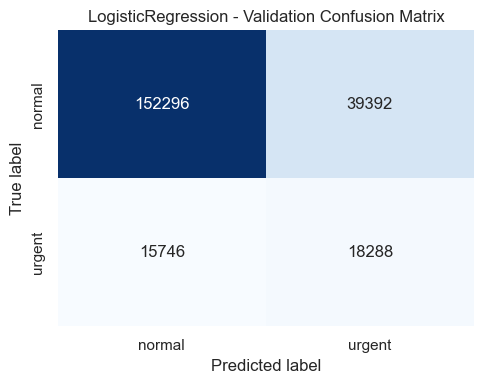

Logistic Regression - Test
Test Accuracy: 0.7548
Test Weighted F1: 0.7790
              precision    recall  f1-score   support

      normal       0.91      0.79      0.85    191991
      urgent       0.31      0.54      0.40     33732

    accuracy                           0.75    225723
   macro avg       0.61      0.67      0.62    225723
weighted avg       0.82      0.75      0.78    225723



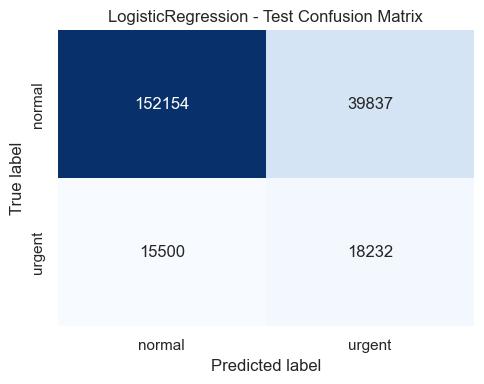

In [61]:
pipe_lr.fit(X_train_features, y_train_enc)

print("Logistic Regression - Validation")
evaluate_pipeline(pipe_lr, X_val_features, y_val_enc, "Validation")

print("Logistic Regression - Test")
evaluate_pipeline(pipe_lr, X_test_features, y_test_enc, "Test")


Random Forest - Validation
Validation Accuracy: 0.6604
Validation Weighted F1: 0.7078
              precision    recall  f1-score   support

      normal       0.92      0.66      0.77    191688
      urgent       0.26      0.68      0.38     34034

    accuracy                           0.66    225722
   macro avg       0.59      0.67      0.57    225722
weighted avg       0.82      0.66      0.71    225722



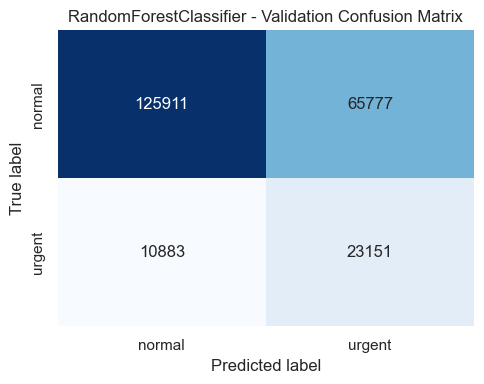

Random Forest - Test
Test Accuracy: 0.6583
Test Weighted F1: 0.7066
              precision    recall  f1-score   support

      normal       0.92      0.65      0.77    191991
      urgent       0.26      0.68      0.37     33732

    accuracy                           0.66    225723
   macro avg       0.59      0.67      0.57    225723
weighted avg       0.82      0.66      0.71    225723



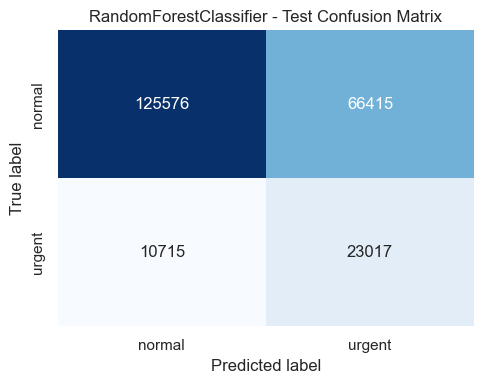

In [62]:
pipe_rf.fit(X_train_features, y_train_enc)

print("Random Forest - Validation")
evaluate_pipeline(pipe_rf, X_val_features, y_val_enc, "Validation")

print("Random Forest - Test")
evaluate_pipeline(pipe_rf, X_test_features, y_test_enc, "Test")


XGBoost - Validation
Validation Accuracy: 0.8776
Validation Weighted F1: 0.8450
              precision    recall  f1-score   support

      normal       0.88      0.99      0.93    191688
      urgent       0.87      0.22      0.35     34034

    accuracy                           0.88    225722
   macro avg       0.87      0.61      0.64    225722
weighted avg       0.88      0.88      0.84    225722



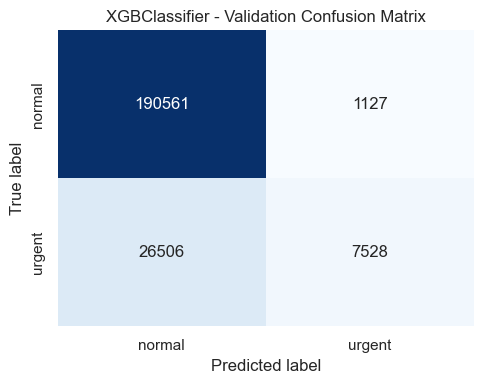

XGBoost - Test
Test Accuracy: 0.8790
Test Weighted F1: 0.8468
              precision    recall  f1-score   support

      normal       0.88      0.99      0.93    191991
      urgent       0.87      0.22      0.35     33732

    accuracy                           0.88    225723
   macro avg       0.88      0.61      0.64    225723
weighted avg       0.88      0.88      0.85    225723



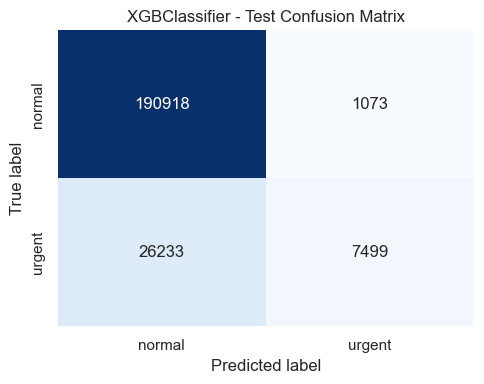

In [63]:
pipe_xgb.fit(X_train_features, y_train_enc)

print("XGBoost - Validation")
evaluate_pipeline(pipe_xgb, X_val_features, y_val_enc, "Validation")

print("XGBoost - Test")
evaluate_pipeline(pipe_xgb, X_test_features, y_test_enc, "Test")
